### **BASELINE 1 IMPLEMENTATION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
german_train = pd.read_csv("/content/train_v1.4.tsv", sep="\t", header=None)
german_test = pd.read_csv("/content/set_v1.4.tsv", sep="\t", header=None)

In [3]:
german_train.columns = ["id", "text", "relevance", "sentiment", "aspect"]
german_test.columns = ["id", "text", "relevance", "sentiment", "aspect"]

In [4]:
print(german_train.head())
print(german_train.columns)

                                                  id  \
0  http://twitter.com/reneesa\_devin/statuses/628...   
1  http://twitter.com/MrElch/statuses/68737328126...   
2  http://twitter.com/wolfi\_wiese/statuses/64924...   
3  http://wirtschaftsnachrichten-online.de/2015/1...   
4  http://community.bahn.de/questions/1034649-db-...   

                                                text  relevance sentiment  \
0  @DB_Bahn ja, weil in Wuppertal Bauarbeiten sin...       True   neutral   
1  @nordschaf theoretisch kannste dir überall im ...       True  positive   
2  Bahn verspätet sich..gleich kommt noch jemand ...       True  negative   
3  Ihre Anfragen brachten uns zu neuen Leistungen...      False   neutral   
4  Kann ich mit dem DB Geschenk Ticket den ICE Sp...       True   neutral   

                                              aspect  
0                            Allgemein#Haupt:neutral  
1  Zugfahrt#Streckennetz:positive Zugfahrt#Fahrtz...  
2                    Zugfahrt#Pünkt

In [5]:
german_train = german_train[["text", "sentiment"]]
german_test = german_test[["text", "sentiment"]]

In [6]:
german_train.dropna(inplace=True)
german_test.dropna(inplace=True)

In [7]:
print(german_train["sentiment"].value_counts())

sentiment
neutral     14415
negative     5228
positive     1216
Name: count, dtype: int64


In [8]:
turkish_data = pd.read_csv("/content/turkish_test.csv")

In [9]:
print(turkish_data.head())
print(turkish_data.columns)

                                                text     label         dataset
0      Kral akbaba dikkat çekici renklere sahiptir .      Notr            wiki
1   ısrarla korkutmayı başarıyor. sanki korku çok...  Positive           HUMIR
2  Neşe ve Üzüntü köprünün kırılmaya başlamasıyla...      Notr            wiki
3  i phone 5 ten sonra gene 4'' ekranı tercih ett...  Positive  urun_yorumlari
4    Beşinci sezonda diziye yeni oyuncular katıldı .      Notr            wiki
Index(['text', 'label', 'dataset'], dtype='object')


In [10]:
print(turkish_data["label"].value_counts())

label
Positive    26217
Notr        17092
Negative     5656
Name: count, dtype: int64


In [11]:
turkish_data["label"] = turkish_data["label"].replace({
    "Positive": "positive",
    "Negative": "negative",
    "Notr": "neutral"
})

In [12]:
turkish_data = turkish_data[["text", "label"]]

In [13]:
turkish_data.columns = ["text", "sentiment"]

In [14]:
print(turkish_data.head())
print(turkish_data.columns)

                                                text sentiment
0      Kral akbaba dikkat çekici renklere sahiptir .   neutral
1   ısrarla korkutmayı başarıyor. sanki korku çok...  positive
2  Neşe ve Üzüntü köprünün kırılmaya başlamasıyla...   neutral
3  i phone 5 ten sonra gene 4'' ekranı tercih ett...  positive
4    Beşinci sezonda diziye yeni oyuncular katıldı .   neutral
Index(['text', 'sentiment'], dtype='object')


In [15]:
print(turkish_data["sentiment"].value_counts())

sentiment
positive    26217
neutral     17092
negative     5656
Name: count, dtype: int64


In [16]:
X_train_ger = german_train["text"]
y_train_ger = german_train["sentiment"]

X_test_ger = german_test["text"]
y_test_ger = german_test["sentiment"]

X_test_tur = turkish_data["text"]
y_test_tur = turkish_data["sentiment"]

In [17]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_ger_tfidf = vectorizer.fit_transform(X_train_ger)

X_test_ger_tfidf = vectorizer.transform(X_test_ger)

X_test_tur_tfidf = vectorizer.transform(X_test_tur)

In [18]:
baseline_model = LogisticRegression(max_iter=1000)

In [19]:
baseline_model.fit(X_train_ger_tfidf,y_train_ger)

LogisticRegression(max_iter=1000)

In [20]:
y_pred_ger = baseline_model.predict(X_test_ger_tfidf)

In [21]:
accuracy_ger = accuracy_score(y_test_ger,y_pred_ger)

print("German to German Accuracy:", accuracy_ger)

German to German Accuracy: 0.8128894579598805


In [22]:
print(classification_report(y_test_ger,y_pred_ger))

              precision    recall  f1-score   support

    negative       0.79      0.54      0.64      5845
     neutral       0.82      0.95      0.88     16214
    positive       0.81      0.32      0.46      1371

    accuracy                           0.81     23430
   macro avg       0.81      0.60      0.66     23430
weighted avg       0.81      0.81      0.80     23430



In [23]:
print(confusion_matrix(y_test_ger,y_pred_ger))

[[ 3170  2661    14]
 [  687 15438    89]
 [  131   802   438]]


In [24]:
y_pred_tur = baseline_model.predict(X_test_tur_tfidf)

In [25]:
accuracy_tur = accuracy_score(y_test_tur,y_pred_tur)

print("German to Turkish Accuracy:", accuracy_tur)

German to Turkish Accuracy: 0.3490043908914531


In [26]:
print(classification_report(y_test_tur,y_pred_tur))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.08      0.00      0.00      5656
     neutral       0.35      1.00      0.52     17092
    positive       0.00      0.00      0.00     26217

    accuracy                           0.35     48965
   macro avg       0.14      0.33      0.17     48965
weighted avg       0.13      0.35      0.18     48965



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
print(confusion_matrix(y_test_tur,y_pred_tur))

[[    9  5647     0]
 [   12 17080     0]
 [   86 26131     0]]


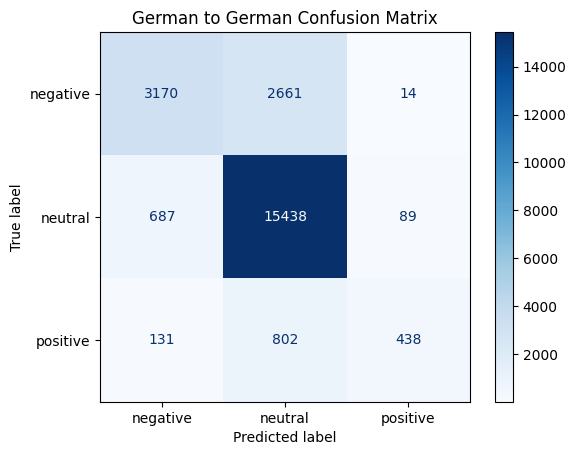

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test_ger, y_pred_ger, cmap="Blues")

plt.title("German to German Confusion Matrix")
plt.show()

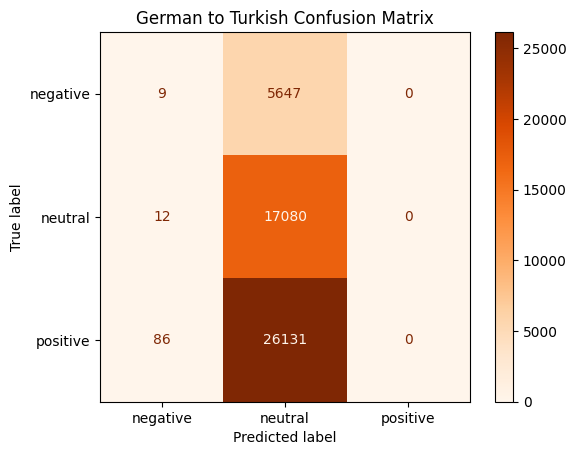

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test_tur, y_pred_tur, cmap="Oranges")

plt.title("German to Turkish Confusion Matrix")

plt.show()

### **BASELINE 2 IMPLEMENTATION**

In [30]:
!pip install transformers datasets sentencepiece accelerate -q

In [31]:
import torch
from datasets import Dataset
from transformers import (XLMRobertaTokenizer, XLMRobertaForSequenceClassification, Trainer, TrainingArguments)

In [32]:
label_mapping = {"negative": 0, "neutral": 1, "positive": 2}

y_train_encoded = [label_mapping[label] for label in y_train_ger]

y_test_encoded = [label_mapping[label] for label in y_test_ger]

In [33]:
train_df = pd.DataFrame({"text": X_train_ger, "label": y_train_encoded})

test_df = pd.DataFrame({"text": X_test_ger, "label": y_test_encoded})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [34]:
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [35]:
def tokenize_function(example):
  return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/20859 [00:00<?, ? examples/s]

Map:   0%|          | 0/23430 [00:00<?, ? examples/s]

In [36]:
model = XLMRobertaForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=3)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no"
)

In [38]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [39]:
trainer.train()

Step,Training Loss
50,0.839321
100,0.811017
150,0.786070
200,0.851965
250,0.725931
300,0.828081
350,0.809263
400,0.748873
450,0.684321
500,0.726297


TrainOutput(global_step=5216, training_loss=0.5289600709098979, metrics={'train_runtime': 282.1228, 'train_samples_per_second': 147.872, 'train_steps_per_second': 18.488, 'total_flos': 2744141390194176.0, 'train_loss': 0.5289600709098979, 'epoch': 2.0})

In [40]:
german_predictions = trainer.predict(test_dataset)

german_pred_labels = np.argmax(german_predictions.predictions, axis=1)

accuracy_ger_xlmr = accuracy_score(y_test_encoded, german_pred_labels)

print("German-to-German XLM-R Accuracy:")
print(accuracy_ger_xlmr)

German-to-German XLM-R Accuracy:
0.8765258215962441


In [41]:
print(classification_report(y_test_encoded, german_pred_labels))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      5845
           1       0.91      0.92      0.92     16214
           2       0.69      0.63      0.66      1371

    accuracy                           0.88     23430
   macro avg       0.80      0.79      0.80     23430
weighted avg       0.88      0.88      0.88     23430



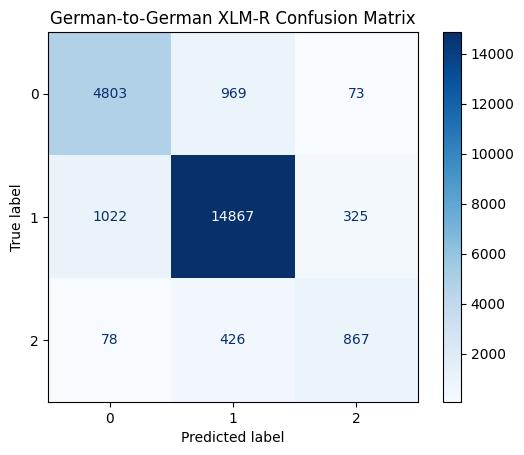

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test_encoded, german_pred_labels, cmap="Blues")

plt.title( "German-to-German XLM-R Confusion Matrix")
plt.show()

In [44]:
turkish_sample = turkish_data.sample(n=200, random_state=42).reset_index(drop=True)

y_true_xlmr = [label_mapping[label] for label in turkish_sample["sentiment"]]

In [45]:
turkish_dataset = Dataset.from_pandas(pd.DataFrame({"text": turkish_sample["text"]}))

turkish_dataset = turkish_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [46]:
turkish_predictions = trainer.predict(turkish_dataset)

turkish_pred_labels = np.argmax(turkish_predictions.predictions, axis=1)

xlmr_accuracy = accuracy_score(y_true_xlmr, turkish_pred_labels)

print("German-to-Turkish XLM-R Accuracy:")
print(xlmr_accuracy)

German-to-Turkish XLM-R Accuracy:
0.46


In [47]:
print(classification_report(y_true_xlmr, turkish_pred_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.41      1.00      0.58        72
           2       1.00      0.19      0.32       106

    accuracy                           0.46       200
   macro avg       0.47      0.40      0.30       200
weighted avg       0.68      0.46      0.38       200



In [48]:
print(confusion_matrix(y_true_xlmr, turkish_pred_labels))

[[ 0 22  0]
 [ 0 72  0]
 [ 3 83 20]]


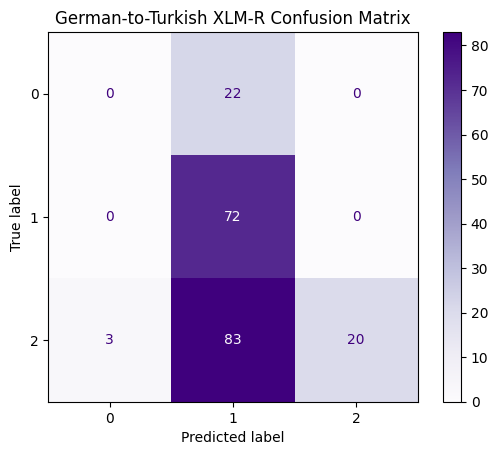

In [49]:
ConfusionMatrixDisplay.from_predictions(y_true_xlmr, turkish_pred_labels, cmap="Purples")

plt.title("German-to-Turkish XLM-R Confusion Matrix")
plt.show()